Loading files...
  OK  Full Model (Teacher)           451 steps | per-step: yes
  OK  LoRA Rank32                    451 steps | per-step: yes
  OK  No CoT 4-Steps                 451 steps | per-step: yes
  OK  Uniform Loss                   451 steps | per-step: yes
  OK  Zero Penalty                   451 steps | per-step: yes
  OK  Baseline (Standard LoRA)       225 steps | per-step: no


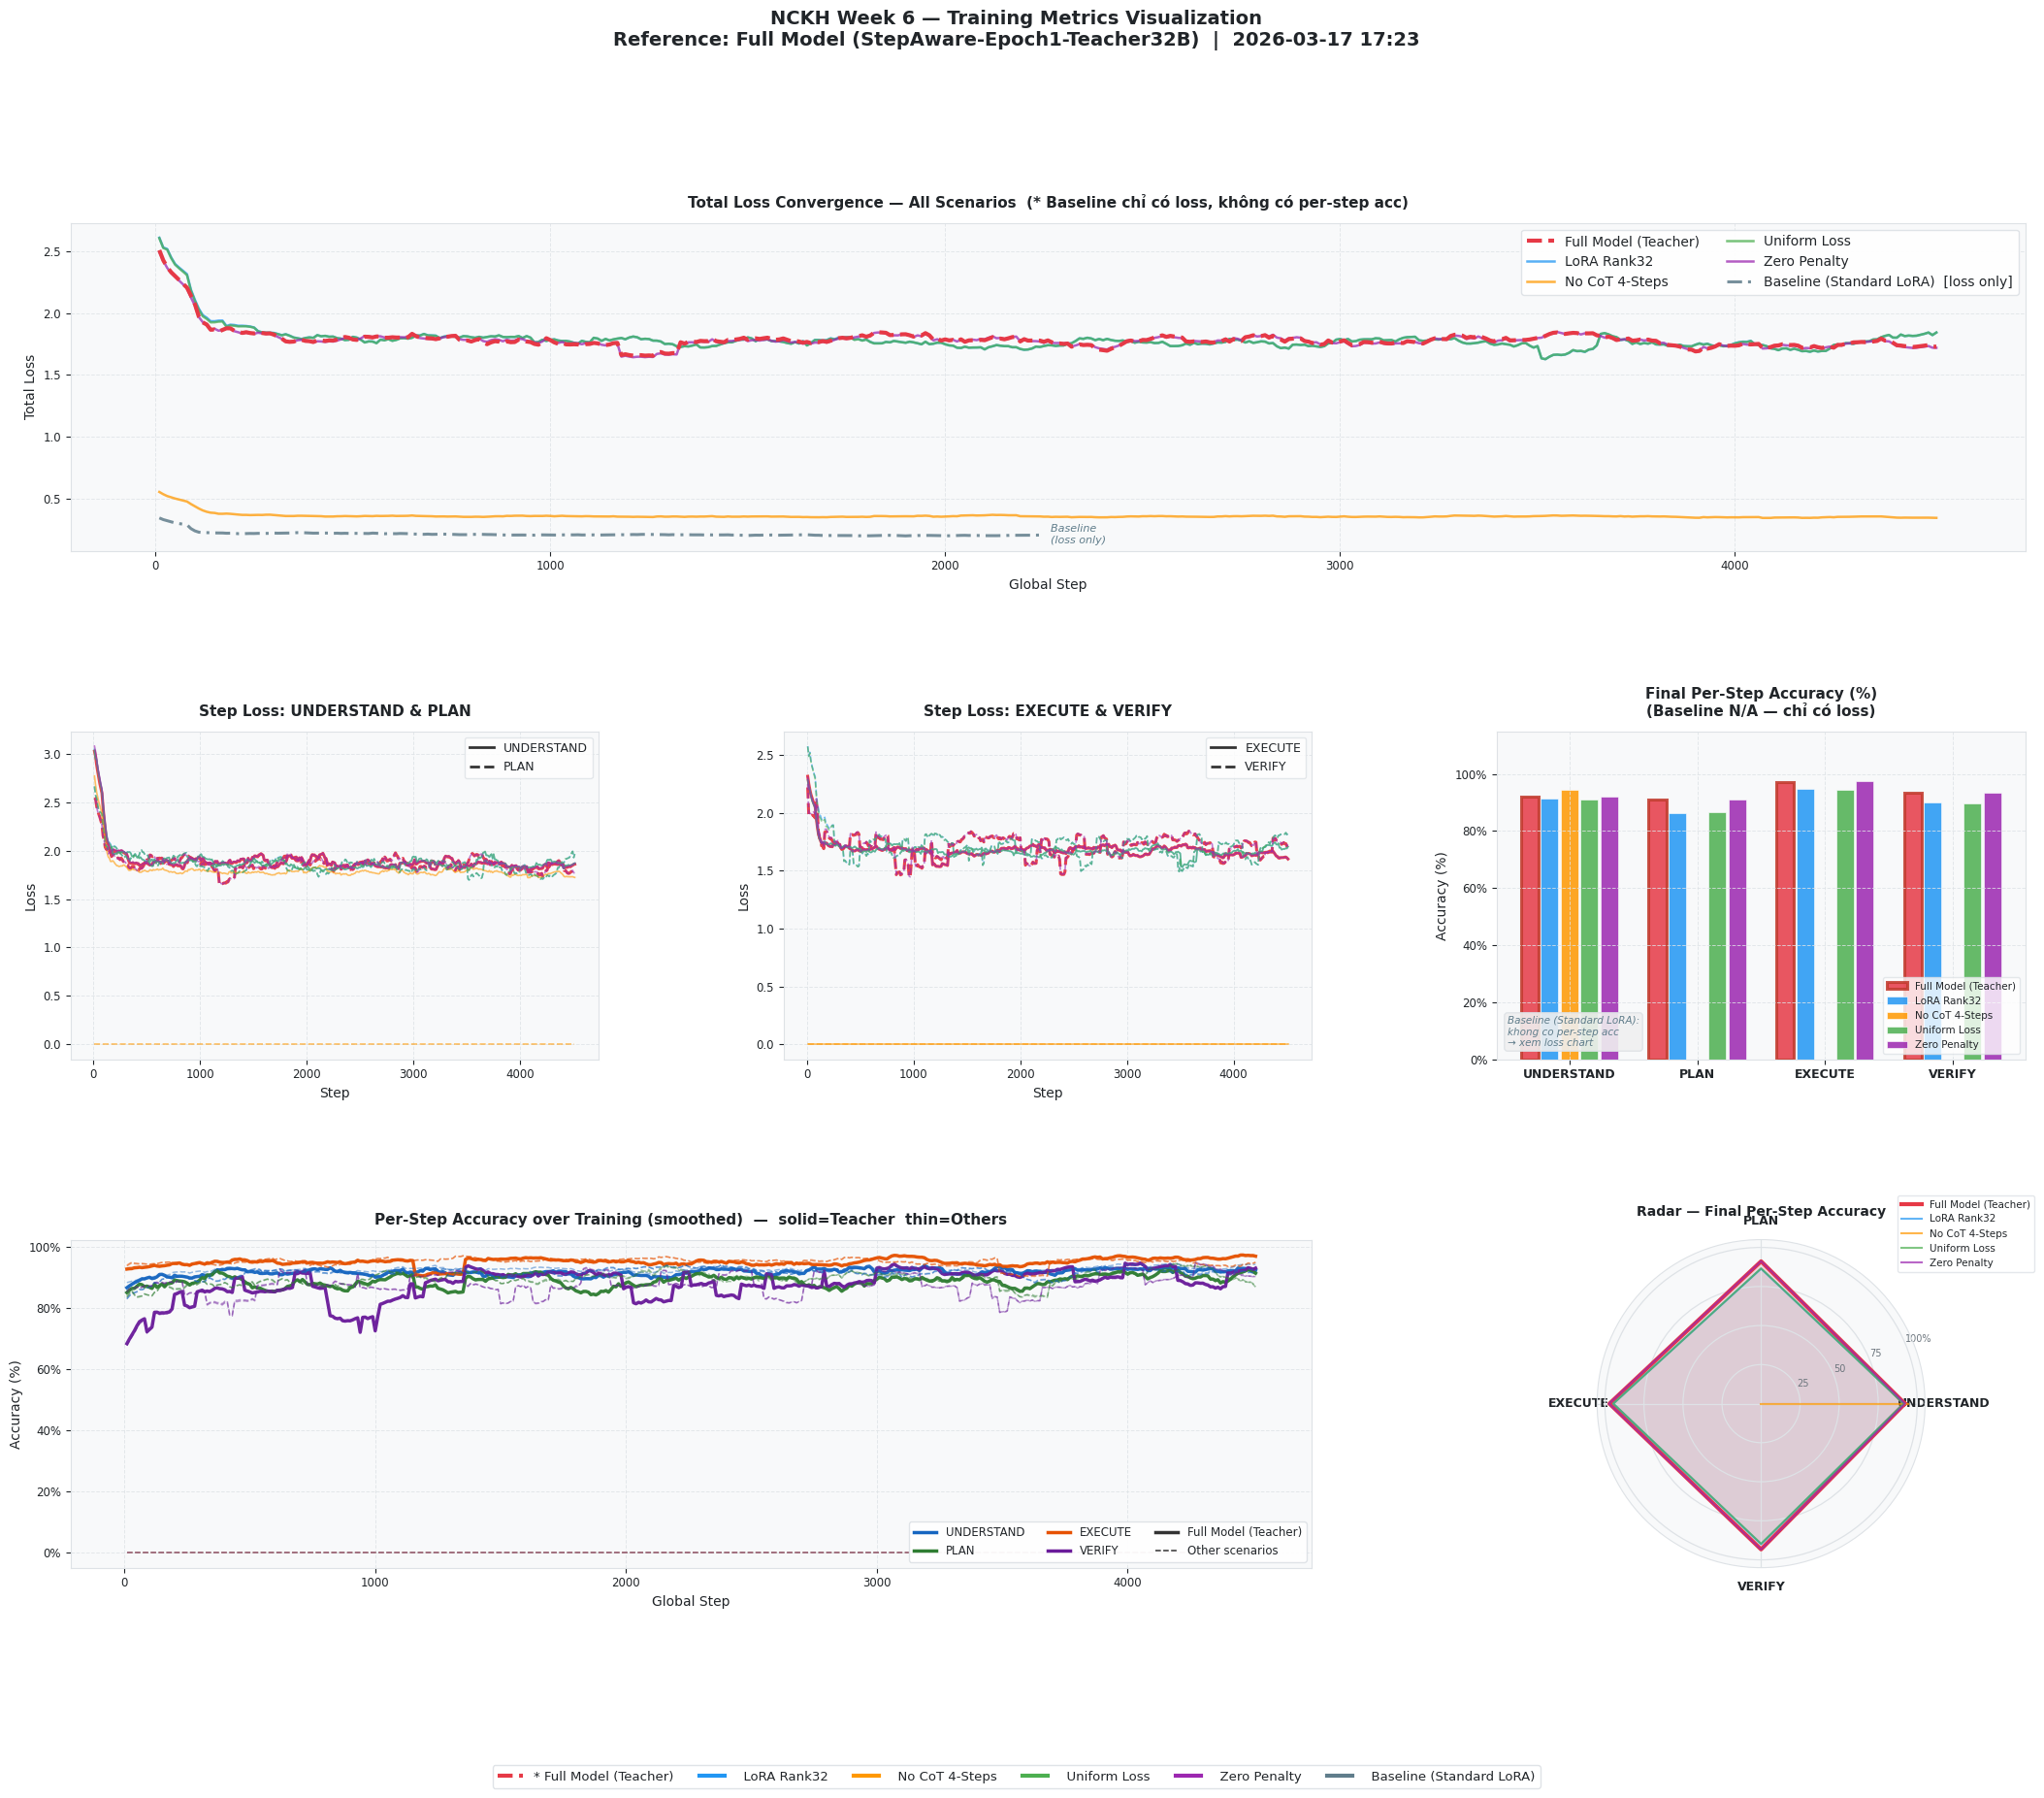


Saved: /kaggle/working/visualization_report.png


In [1]:
"""
NCKH Week 6 — Visualization Script
Chạy trên Kaggle notebook, chỉ cần đổi 5 đường dẫn ở phần CONFIG
"""

### Ablation Study 1 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
from pathlib import Path
from datetime import datetime

# ╔══════════════════════════════════════════════════════════╗
# ║  CONFIG — CHỈ CẦN SỬA PHẦN NÀY                         ║
# ╚══════════════════════════════════════════════════════════╝

FILES = {
    "Full Model (Teacher)": "/kaggle/input/datasets/ductaiphan/stepaware-epoch1-teacher32b/metrics/step_metrics.csv",
    "LoRA Rank32":          "/kaggle/input/datasets/thinguynaas/nckh-week6-lora-rank32/metrics/step_metrics.csv",
    "No CoT 4-Steps":       "/kaggle/input/datasets/thinguynaas/nckh-week6-no-cot-4-steps/metrics/step_metrics.csv",
    "Uniform Loss":         "/kaggle/input/datasets/thinguynaas/nckh-week6-uniform-loss/metrics/step_metrics.csv",
    "Zero Penalty":         "/kaggle/input/datasets/thinguynaas/nckh-week6-zero-penalty/metrics/step_metrics.csv",
    # Baseline — Format B: chỉ có loss, KHÔNG có per-step acc
    "Baseline (Standard LoRA)": "/kaggle/input/datasets/thinguynaas/nckh-week6-baseline-standard-lora/Standard_LoRA/baseline_metrics.csv",
}

OUTPUT_PATH = "/kaggle/working/visualization_report.png"

# ═══════════════════════════════════════════════════════════
# STYLE — Light theme
# ═══════════════════════════════════════════════════════════
BG    = "#ffffff"
PANEL = "#f8f9fa"
GRID  = "#dee2e6"
TEXT  = "#212529"
SUBTEXT = "#6c757d"

PALETTE = [
    "#e63946",  # Full Model → đỏ đậm (nổi bật nhất)
    "#2196F3",  # LoRA Rank32 → xanh dương
    "#FF9800",  # No CoT → cam
    "#4CAF50",  # Uniform Loss → xanh lá
    "#9C27B0",  # Zero Penalty → tím
    "#607D8B",  # Baseline → xám xanh
]

COT_STEPS  = ["understand", "plan", "execute", "verify"]
STEP_LABEL = ["UNDERSTAND", "PLAN", "EXECUTE", "VERIFY"]
STEP_COLOR = ["#1565C0", "#2E7D32", "#E65100", "#6A1B9A"]

# ═══════════════════════════════════════════════════════════
# LOAD & NORMALIZE
# ═══════════════════════════════════════════════════════════
def load(path: str) -> pd.DataFrame | None:
    p = Path(path)
    if not p.exists():
        print(f"  [!] Không tìm thấy: {path}")
        return None
    df = pd.read_csv(p)
    df.columns = [c.strip().lower() for c in df.columns]
    # Normalize step col
    if "global_step" in df.columns:
        df = df.rename(columns={"global_step": "step"})
    elif "step" not in df.columns:
        df["step"] = range(len(df))
    # Normalize loss col
    if "total_loss" not in df.columns and "loss" in df.columns:
        df["total_loss"] = df["loss"]
    return df

def smooth(s, w=15):
    return pd.Series(s).rolling(w, min_periods=1, center=True).mean().values

def final_acc(df, step=10):
    """Trung bình acc của tail để tránh noise."""
    tail = df.tail(step)
    out = {}
    for s in COT_STEPS:
        col = f"{s}_acc"
        if col in df.columns:
            out[s] = round(tail[col].mean() * 100, 1)
    return out

# ═══════════════════════════════════════════════════════════
# LOAD ALL
# ═══════════════════════════════════════════════════════════
print("Loading files...")
data = {}
for name, path in FILES.items():
    df = load(path)
    if df is not None:
        data[name] = df
        has_steps = any(f"{s}_acc" in df.columns for s in COT_STEPS)
        print(f"  OK  {name:<30} {len(df)} steps | per-step: {'yes' if has_steps else 'no'}")

names  = list(data.keys())
colors = {n: PALETTE[i] for i, n in enumerate(names)}
TEACHER = names[0]  # First entry = Full Model

# ═══════════════════════════════════════════════════════════
# FIGURE LAYOUT — 5 panels
# ═══════════════════════════════════════════════════════════
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.edgecolor": GRID,
})
fig = plt.figure(figsize=(26, 18))
fig.patch.set_facecolor(BG)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.35)

def ax_style(ax, title):
    ax.set_facecolor(PANEL)
    ax.set_title(title, color=TEXT, fontsize=11, fontweight="bold", pad=11)
    ax.tick_params(colors=TEXT, labelsize=8.5)
    ax.yaxis.label.set_color(TEXT)
    ax.xaxis.label.set_color(TEXT)
    for sp in ax.spines.values():
        sp.set_edgecolor(GRID)
        sp.set_linewidth(0.8)
    ax.grid(color=GRID, linewidth=0.7, alpha=0.8, linestyle="--")

# ══════════════════════════════════════════════════════
# Panel 1 (row 0, span all): Total Loss Convergence
# ══════════════════════════════════════════════════════
ax1 = fig.add_subplot(gs[0, :])
ax_style(ax1, "Total Loss Convergence — All Scenarios  (* Baseline chỉ có loss, không có per-step acc)")

for name, df in data.items():
    if "total_loss" not in df.columns:
        continue
    is_teacher  = name == TEACHER
    is_baseline = "Baseline" in name
    has_steps   = any(f"{s}_acc" in df.columns for s in COT_STEPS)

    # Baseline: đường đứt nét dày, marker đặc biệt
    if is_baseline:
        ax1.plot(
            df["step"].values,
            smooth(df["total_loss"].values),
            label=f"{name}  [loss only]",
            color=colors[name],
            linewidth=2.2,
            linestyle=(0, (5, 2, 1, 2)),   # dash-dot
            alpha=0.85,
            zorder=6,
        )
        # Annotation ở điểm cuối
        last_step = df["step"].values[-1]
        last_loss = smooth(df["total_loss"].values)[-1]
        ax1.annotate(
            f"  Baseline\n  (loss only)",
            xy=(last_step, last_loss),
            color=colors[name],
            fontsize=8, fontstyle="italic",
            va="center",
        )
    else:
        ax1.plot(
            df["step"].values,
            smooth(df["total_loss"].values),
            label=name,
            color=colors[name],
            linewidth=3.0 if is_teacher else 1.8,
            linestyle="--" if is_teacher else "-",
            alpha=1.0 if is_teacher else 0.75,
            zorder=10 if is_teacher else 5,
        )

ax1.set_xlabel("Global Step", fontsize=10)
ax1.set_ylabel("Total Loss", fontsize=10)
ax1.legend(facecolor="white", labelcolor=TEXT, fontsize=10,
           loc="upper right", framealpha=0.95, ncol=2,
           edgecolor=GRID)

# ══════════════════════════════════════════════════════
# Panel 2 (row 1, col 0): Per-Step Loss — UNDERSTAND & PLAN
# ══════════════════════════════════════════════════════
ax2 = fig.add_subplot(gs[1, 0])
ax_style(ax2, "Step Loss: UNDERSTAND & PLAN")

for name, df in data.items():
    is_teacher = name == TEACHER
    lw = 2.2 if is_teacher else 1.2
    alpha = 0.95 if is_teacher else 0.6
    for s, ls in [("understand", "-"), ("plan", "--")]:
        col = f"{s}_loss"
        if col not in df.columns: continue
        label = f"{name} [{s.upper()}]" if is_teacher else None
        ax2.plot(df["step"].values, smooth(df[col].values),
                 color=colors[name], linewidth=lw,
                 linestyle=ls, alpha=alpha, label=label)

# Legend chỉ cho line style
h = [Line2D([0],[0], color="#333", lw=2, ls="-",  label="UNDERSTAND"),
     Line2D([0],[0], color="#333", lw=2, ls="--", label="PLAN")]
ax2.legend(handles=h, facecolor="white", labelcolor=TEXT, fontsize=9, edgecolor=GRID)
ax2.set_xlabel("Step"); ax2.set_ylabel("Loss")

# ══════════════════════════════════════════════════════
# Panel 3 (row 1, col 1): Per-Step Loss — EXECUTE & VERIFY
# ══════════════════════════════════════════════════════
ax3 = fig.add_subplot(gs[1, 1])
ax_style(ax3, "Step Loss: EXECUTE & VERIFY")

for name, df in data.items():
    is_teacher = name == TEACHER
    lw = 2.2 if is_teacher else 1.2
    alpha = 0.95 if is_teacher else 0.6
    for s, ls in [("execute", "-"), ("verify", "--")]:
        col = f"{s}_loss"
        if col not in df.columns: continue
        ax3.plot(df["step"].values, smooth(df[col].values),
                 color=colors[name], linewidth=lw,
                 linestyle=ls, alpha=alpha)

h = [Line2D([0],[0], color="#333", lw=2, ls="-",  label="EXECUTE"),
     Line2D([0],[0], color="#333", lw=2, ls="--", label="VERIFY")]
ax3.legend(handles=h, facecolor="white", labelcolor=TEXT, fontsize=9, edgecolor=GRID)
ax3.set_xlabel("Step"); ax3.set_ylabel("Loss")

# ══════════════════════════════════════════════════════
# Panel 4 (row 1, col 2): Per-Step Accuracy — Final Bar
# ══════════════════════════════════════════════════════
ax4 = fig.add_subplot(gs[1, 2])
ax_style(ax4, "Final Per-Step Accuracy (%)\n(Baseline N/A — chỉ có loss)")

step_colors_map = dict(zip(COT_STEPS, STEP_COLOR))
x = np.arange(len(COT_STEPS))
# Chỉ vẽ các scenario CÓ per-step acc
names_with_acc = [n for n in names if any(f"{s}_acc" in data[n].columns for s in COT_STEPS)]
n = len(names_with_acc)
total_w = 0.78
w = total_w / n

for i, name in enumerate(names_with_acc):
    df   = data[name]
    accs = final_acc(df)
    vals = [accs.get(s, 0) for s in COT_STEPS]
    offset = (i - n/2 + 0.5) * w
    is_teacher = name == TEACHER
    ax4.bar(
        x + offset, vals, w * 0.88,
        color=colors[name],
        edgecolor="#c0392b" if is_teacher else "white",
        linewidth=2.2 if is_teacher else 0.5,
        alpha=0.85,
        label=name,
    )

# Ghi chú baseline ở góc
ax4.text(0.02, 0.04,
         "Baseline (Standard LoRA):\nkhong co per-step acc\n→ xem loss chart",
         transform=ax4.transAxes, fontsize=7.5,
         color=colors.get("Baseline (Standard LoRA)", "#607D8B"),
         fontstyle="italic",
         bbox=dict(boxstyle="round,pad=0.3", facecolor="#f0f0f0",
                   edgecolor=GRID, alpha=0.9))

ax4.set_xticks(x)
ax4.set_xticklabels(STEP_LABEL, color=TEXT, fontsize=9, fontweight="bold")
ax4.set_ylabel("Accuracy (%)")
ax4.set_ylim(0, 115)
ax4.yaxis.set_major_formatter(ticker.PercentFormatter(decimals=0))
ax4.legend(facecolor="white", labelcolor=TEXT, fontsize=7.5,
           loc="lower right", edgecolor=GRID)

# ══════════════════════════════════════════════════════
# Panel 5 (row 2, col 0-1): Per-Step Accuracy over Training
# ══════════════════════════════════════════════════════
ax5 = fig.add_subplot(gs[2, :2])
ax_style(ax5, "Per-Step Accuracy over Training (smoothed)  —  solid=Teacher  thin=Others")

for name, df in data.items():
    is_teacher = name == TEACHER
    lw    = 2.5 if is_teacher else 1.1
    alpha = 0.95 if is_teacher else 0.45
    ls    = "-" if is_teacher else "-"
    for s, sc in zip(COT_STEPS, STEP_COLOR):
        col = f"{s}_acc"
        if col not in df.columns: continue
        ax5.plot(
            df["step"].values,
            smooth(df[col].values * 100, w=20),
            color=sc,
            linewidth=lw,
            alpha=alpha,
            linestyle="--" if not is_teacher else "-",
        )

# Legend: màu = step, độ đậm = teacher vs others
step_h  = [Line2D([0],[0], color=sc, lw=2.5, label=sl)
           for sc, sl in zip(STEP_COLOR, STEP_LABEL)]
style_h = [Line2D([0],[0], color="#333", lw=2.5, ls="-",  label="Full Model (Teacher)"),
           Line2D([0],[0], color="#333", lw=1.1, ls="--", label="Other scenarios")]
ax5.legend(handles=step_h + style_h, facecolor="white", labelcolor=TEXT,
           fontsize=8.5, loc="lower right", ncol=3, framealpha=0.95, edgecolor=GRID)
ax5.set_xlabel("Global Step", fontsize=10)
ax5.set_ylabel("Accuracy (%)", fontsize=10)
ax5.yaxis.set_major_formatter(ticker.PercentFormatter(decimals=0))

# ══════════════════════════════════════════════════════
# Panel 6 (row 2, col 2): Radar — Final Accuracy
# ══════════════════════════════════════════════════════
ax6 = fig.add_subplot(gs[2, 2], polar=True)
ax6.set_facecolor(PANEL)
ax6.set_title("Radar — Final Per-Step Accuracy",
              color=TEXT, fontsize=10, fontweight="bold", pad=18)

N      = len(COT_STEPS)
angles = [n_i / N * 2 * np.pi for n_i in range(N)]
angles += angles[:1]

ax6.set_xticks(angles[:-1])
ax6.set_xticklabels(STEP_LABEL, color=TEXT, fontsize=9, fontweight="bold")
ax6.set_ylim(0, 105)
ax6.set_yticks([25, 50, 75, 100])
ax6.set_yticklabels(["25", "50", "75", "100%"], color=SUBTEXT, fontsize=7)
ax6.grid(color=GRID, linewidth=0.9)
ax6.spines["polar"].set_edgecolor(GRID)

for name, df in data.items():
    if "Baseline" in name:
        continue   # skip — không có per-step acc
    accs = final_acc(df)
    if not accs: continue
    is_teacher = name == TEACHER
    vals = [accs.get(s, 0) for s in COT_STEPS] + [accs.get(COT_STEPS[0], 0)]
    ax6.plot(angles, vals, color=colors[name],
             linewidth=3.0 if is_teacher else 1.5,
             alpha=1.0 if is_teacher else 0.7,
             label=name)
    ax6.fill(angles, vals, color=colors[name],
             alpha=0.15 if is_teacher else 0.05)

ax6.legend(facecolor="white", labelcolor=TEXT, edgecolor=GRID,
           fontsize=7.5, loc="upper right",
           bbox_to_anchor=(1.35, 1.15))

# ══════════════════════════════════════════════════════
# COLOR LEGEND (scenario → color) ở dưới cùng
# ══════════════════════════════════════════════════════
legend_handles = [
    Line2D([0],[0], color=colors[n], lw=3,
           linestyle="--" if n == TEACHER else "-",
           label=("* " if n == TEACHER else "  ") + n)
    for n in names
]
fig.legend(handles=legend_handles,
           loc="lower center", ncol=len(names),
           facecolor="white", labelcolor=TEXT,
           fontsize=9.5, framealpha=0.95,
           edgecolor=GRID,
           bbox_to_anchor=(0.5, -0.02))

# ══════════════════════════════════════════════════════
fig.suptitle(
    f"NCKH Week 6 — Training Metrics Visualization\n"
    f"Reference: Full Model (StepAware-Epoch1-Teacher32B)  |  "
    f"{datetime.now().strftime('%Y-%m-%d %H:%M')}",
    color=TEXT, fontsize=14, fontweight="bold", y=1.002,
)

plt.savefig(OUTPUT_PATH, dpi=160, bbox_inches="tight", facecolor=BG)
plt.show()
print(f"\nSaved: {OUTPUT_PATH}")

In [2]:
# ══════════════════════════════════════════════════════
# EXPORT — Full Summary CSV (per-step acc + loss + steps)
# ══════════════════════════════════════════════════════
import pandas as pd

CSV_OUTPUT = "/kaggle/working/final_per_step_accuracy.csv"

rows = []
for name, df in data.items():
    accs = final_acc(df)  # trung bình tail 10 steps
    
    row = {"model": name}
    
    # Per-step accuracy (None nếu Baseline)
    for s in COT_STEPS:
        row[s.upper() + "_acc"] = accs.get(s, None)
    
    # Trung bình 4 bước
    vals = [v for v in [accs.get(s) for s in COT_STEPS] if v is not None]
    row["avg_step_acc"] = round(sum(vals) / len(vals), 1) if vals else None

    # Per-step loss cuối (tail 10)
    for s in COT_STEPS:
        col = f"{s}_loss"
        if col in df.columns:
            row[s.upper() + "_loss"] = round(df[col].tail(10).mean(), 4)
        else:
            row[s.upper() + "_loss"] = None

    # Total loss cuối
    if "total_loss" in df.columns:
        row["total_loss_final"] = round(df["total_loss"].tail(10).mean(), 4)
        row["total_loss_min"]   = round(df["total_loss"].min(), 4)
    else:
        row["total_loss_final"] = None
        row["total_loss_min"]   = None

    # Số steps
    row["total_steps"] = int(df["step"].max()) if "step" in df.columns else len(df)
    
    # Has per-step acc?
    row["has_per_step_acc"] = "yes" if accs else "no"

    rows.append(row)

cols = [
    "model",
    "UNDERSTAND_acc", "PLAN_acc", "EXECUTE_acc", "VERIFY_acc", "avg_step_acc",
    "UNDERSTAND_loss", "PLAN_loss", "EXECUTE_loss", "VERIFY_loss",
    "total_loss_final", "total_loss_min",
    "total_steps", "has_per_step_acc"
]

df_export = pd.DataFrame(rows, columns=cols)
df_export.to_csv(CSV_OUTPUT, index=False)

print("✅ Exported:", CSV_OUTPUT)
print()
print(df_export.to_string(index=False))


✅ Exported: /kaggle/working/final_per_step_accuracy.csv

                   model  UNDERSTAND_acc  PLAN_acc  EXECUTE_acc  VERIFY_acc  avg_step_acc  UNDERSTAND_loss  PLAN_loss  EXECUTE_loss  VERIFY_loss  total_loss_final  total_loss_min  total_steps has_per_step_acc
    Full Model (Teacher)            92.1      91.1         97.1        93.3          93.4           1.8491     1.7978        1.6172       1.7328            1.7409          0.3710         4510              yes
             LoRA Rank32            91.4      86.4         94.7        90.0          90.6           1.8540     1.9936        1.6939       1.8270            1.8425          0.3246         4510              yes
          No CoT 4-Steps            94.3       0.0          0.0         0.0          23.6           1.7317     0.0000        0.0000       0.0000            0.3463          0.3282         4510              yes
            Uniform Loss            91.2      86.6         94.6        89.7          90.5           1.8535 